# General Task Performance 

In [294]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [295]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import LLM_MODELS, ACS_TASKS, TABLESHIFT_TASKS, BASELINES, FIGURES_ROOT_DIR, RESULTS_CSV_SAME_PROMPT

from monoculture.analysis.utils import (
    key_to_model,
    model_to_key,
    prettify_model_name,
    get_size,
    is_instruction_tuned,
    load_model_outputs_same_prompt,
    get_metric,
    load_results_overview,
    add_evals_to_df,
    load_data_if_needed,
    filter_results,
    filter_models_better_const, 
    filter_top_models_by_eps,
    df_to_dict
)
from monoculture.baseline.utils import load_baselines

from monoculture.analysis.plotting import (
    plot_accuracies,
    plot_label_dist,
    plot_general_performance_task
)

In [296]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [350]:
select_by='balanced_accuracy' # 'accuracy' # 

## Load Task Data

In [351]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

Already defined, update if needed.


## Load Baselines

In [352]:
baseline_scores, baseline_evals = load_baselines(baselines=BASELINES, tasks=TASKS)

baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSIncome/Constant_bench-211220205'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSIncome/LogisticRegression_bench-790429520'.
- GBM: Load predictions from 'results/baselines/model-GBM/GBM_task-ACSIncome/GBM_bench-996001762'.
- XGBoost: Load predictions from 'results/baselines/model-XGBoost/XGBoost_task-ACSIncome/XGBoost_bench-3794332052'.
- NN: Load predictions from 'results/baselines/model-NN/NN_task-ACSIncome/NN_bench-276142988'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSEmployment/Constant_bench-1469218015'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSEmployment/LogisticRegression_bench-2439278790'.
- GBM: Load predictions from 'results/baselines/model-

,Constant,LogisticRegression,GBM,XGBoost,NN
238351,0,0,0,0,0
2995677,0,0,0,0,0
2360043,0,0,1,1,1
1924596,0,0,0,0,0
2803585,0,0,0,0,0


In [353]:
print(f"{'baseline':20} & " + " & ".join(TASKS) + "\\\\")
for baseline in BASELINES:
    row = f"{baseline:20} & "
    for task in TASKS:
        row += f"\t{baseline_evals[task][baseline]['balanced_accuracy']:.4f} & "
    print(row[:-2]+"\\\\")

baseline             & ACSIncome & ACSEmployment & ACSMobility & ACSTravelTime & ACSPublicCoverage & BRFSS_Diabetes & BRFSS_Blood_Pressure\\
Constant             & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 \\
LogisticRegression   & 	0.7116 & 	0.7857 & 	0.5164 & 	0.5235 & 	0.5859 & 	0.5253 & 	0.6423 \\
GBM                  & 	0.7952 & 	0.8329 & 	0.5980 & 	0.6663 & 	0.7114 & 	0.5668 & 	0.6607 \\
XGBoost              & 	0.7995 & 	0.8336 & 	0.6055 & 	0.6859 & 	0.7193 & 	0.5710 & 	0.6612 \\
NN                   & 	0.7740 & 	0.8299 & 	0.5516 & 	0.6076 & 	0.6809 & 	0.5322 & 	0.6519 \\


## Load predictions

In [354]:
num_shots = 10
threshold_fitted = True

df = load_results_overview(
    num_shots=num_shots, threshold_fitted=threshold_fitted, same_prompt=True
)
df = df[df["task"].isin(TASKS)]
df.shape

(326, 15)

In [355]:
try:
    assert set(TASKS).issubset(
        set(df["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df['task'].unique())} "
except AssertionError:
    TASKS = list(df["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [356]:
predictions_all = load_model_outputs_same_prompt(
    df, tasks=TASKS, return_risk_scores=False
)

df = add_evals_to_df(df, metrics=["fpr", "fnr", "n_samples", "num_pred_negatives"])

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


## Restrict analysis to models based on performance?

In [357]:
restrict_to_better_const = False
restrict_to_positive_label = False
restrict_to_negative_label = False
restrict_to_top_eps = False
eps = 0.05
restrict_to_topk = False
topk = 10

predictions, data = filter_results(
    predictions=predictions_all.copy(),
    df=df,
    data={t: val for t, val in data_all.items() if t in TASKS},
    tasks=TASKS,
    restrict_to_better_const=restrict_to_better_const,
    restrict_to_positive_label=restrict_to_positive_label,
    restrict_to_negative_label=restrict_to_negative_label,
    restrict_to_top_eps=restrict_to_top_eps,
    restrict_to_topk=restrict_to_topk,
    eps=eps,
    topk=topk,
    acc=select_by
)

In [358]:
{task: predictions[task].shape[1] for task in TASKS}

{'ACSIncome': 48,
 'ACSEmployment': 48,
 'ACSMobility': 46,
 'ACSTravelTime': 46,
 'ACSPublicCoverage': 44,
 'BRFSS_Diabetes': 48,
 'BRFSS_Blood_Pressure': 46}

In [359]:
{task: [mod for mod in LLM_MODELS if model_to_key(mod) not in predictions[task].columns] for task in TASKS}

{'ACSIncome': ['gpt-4.1', 'gpt-3.5-turbo-0125'],
 'ACSEmployment': ['gpt-4.1', 'gpt-3.5-turbo-0125'],
 'ACSMobility': ['google/gemma-1.1-2b-it',
  'allenai/OLMo-2-1124-7B-Instruct',
  'gpt-4.1',
  'gpt-3.5-turbo-0125'],
 'ACSTravelTime': ['google/gemma-1.1-2b-it',
  'allenai/OLMo-7B-Instruct-hf',
  'gpt-4.1',
  'gpt-3.5-turbo-0125'],
 'ACSPublicCoverage': ['google/gemma-1.1-2b-it',
  'google/gemma-2-27b',
  'allenai/OLMo-7B-Instruct-hf',
  'allenai/OLMo-2-1124-7B-Instruct',
  'gpt-4.1',
  'gpt-3.5-turbo-0125'],
 'BRFSS_Diabetes': ['gpt-4.1', 'gpt-3.5-turbo-0125'],
 'BRFSS_Blood_Pressure': ['google/gemma-1.1-2b-it',
  'allenai/OLMo-2-1124-7B-Instruct',
  'gpt-4.1',
  'gpt-3.5-turbo-0125']}

## Plot General Performance

ACSIncome
{'meta-llama--Meta-Llama-3.2-1B-Instruct': 0.5963352358065485, 'allenai--OLMo-2-1124-7B-Instruct': 0.579789726644638, 'google--gemma-2-27b': 0.2745509161910484, 'google--gemma-2-27b-it': 0.4919375187744067, 'meta-llama--Meta-Llama-3-70B': 0.5466866927005106, 'mistralai--Mistral-Small-24B-Base-2501': 0.5813998197656954, 'Qwen--Qwen2.5-72B-Instruct': 0.48593571643136074, 'meta-llama--Meta-Llama-3-8B': 0.4992009612496245, 'meta-llama--Meta-Llama-3.1-70B-Instruct': 0.48362871733253227, 'google--gemma-2-9b': 0.5811895464103334, 'allenai--OLMo-2-1124-7B': 0.6093541604085311, 'meta-llama--Meta-Llama-3-8B-Instruct': 0.5889936917993391, 'Qwen--Qwen2-72B-Instruct': 0.5641093421447883, 'meta-llama--Meta-Llama-3.2-3B': 0.5396875938720337, 'mistralai--Mistral-7B-v0.1': 0.6144007209372184, 'meta-llama--Meta-Llama-3.1-8B': 0.5382637428657254, 'Qwen--Qwen2.5-7B-Instruct': 0.5751396815860619, 'Qwen--Qwen2-7B-Instruct': 0.6258996695704415, 'mistralai--Mistral-7B-Instruct-v0.2': 0.5831420847101

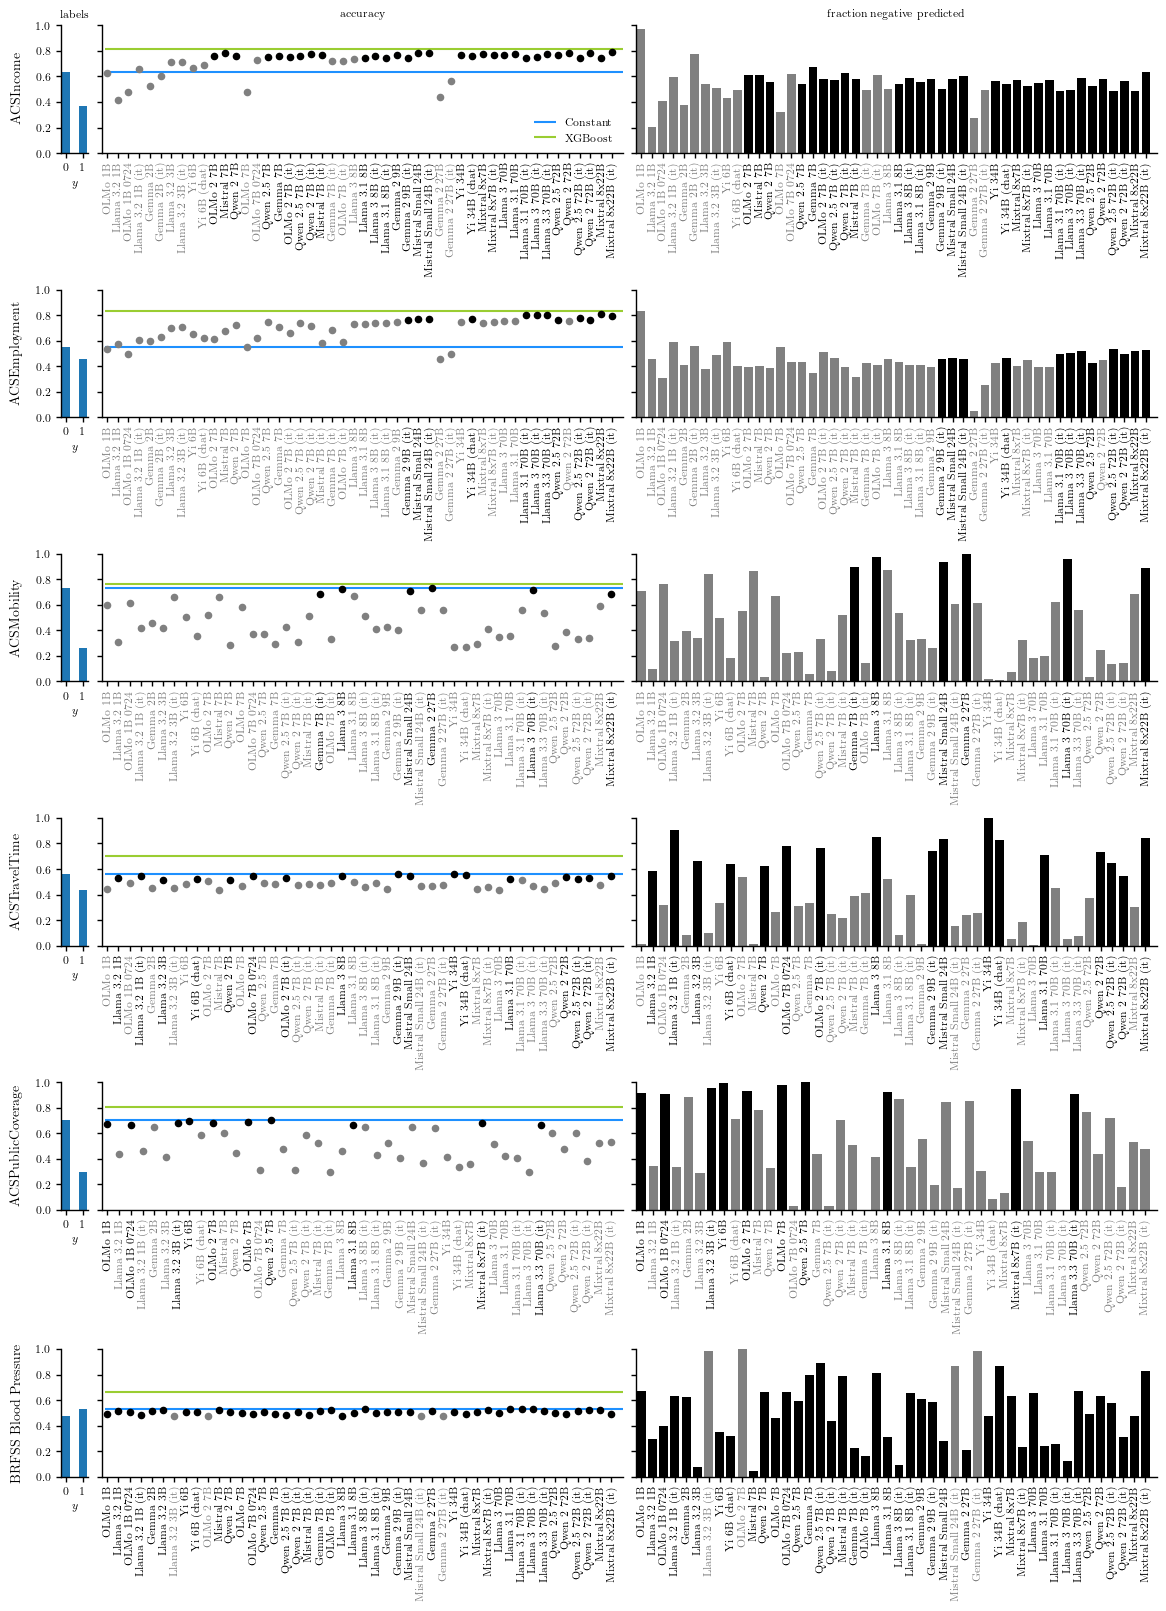

In [363]:
select_by='accuracy'
tasks_to_plot = [task for task in TASKS if task != 'BRFSS_Diabetes']

fig_width = 2.1* plt.rcParams['figure.figsize'][0]
fig_height = 16 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    nrows= len(tasks_to_plot),
    ncols=3,
    figsize=(fig_width, fig_height),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [0.5, 9.5, 9.5]},
    sharey='row'
)


# set column titles
titles = ["labels", select_by.replace('_', ' '), 'fraction negative predicted']
for c, title in enumerate(titles):
    axs[0,c].set_title(title)

for i, task in enumerate(tasks_to_plot):
    print(task)
    ax_label, ax_accuracy, ax_frac_neg = axs[i]
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))

    # task as row label on the left
    ax_label.annotate(
        task.replace("_", " "),
        xy=(0, 0.5),
        xytext=(-ax_label.yaxis.labelpad - 2, 0),
        xycoords=ax_label.yaxis.label,
        textcoords="offset points",
        size="medium",
        ha="right",
        va="center",
        rotation=90,
    )

    y_true = data[task][1]
    # define models to highlight in black
    # models_to_highlight = filter_models_better_const(df[df['task']==task], const_acc=baseline_evals[task]['Constant'][acc], acc=select_by)
    models_to_highlight = filter_top_models_by_eps(df[df['task']==task], acc=select_by)
    plot_general_performance_task(axs[i], df=df[mask], baseline_evals=baseline_evals[task], ytrue=y_true, models_to_highlight=models_to_highlight, acc=select_by)

axs[0, 1].legend(loc='lower right')

file_name = "".join(
    [
        f"performance-{select_by.replace('_','-')}-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
print(file_name)

for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
plt.show()

In [361]:
# one plot per task
tasks_to_plot = [task for task in TASKS if task != 'BRFSS_Diabetes']

fig_width = 2.6*plt.rcParams['figure.figsize'][0]
fig_height = plt.rcParams['figure.figsize'][1]

for i, task in enumerate(tasks_to_plot):
    print(task)

    fig, axs = plt.subplots(
    nrows= 1,
    ncols=3,
    figsize=(fig_width, fig_height),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [0.5, 9.5, 9.5]},
    sharey='row'
    )
    
    ax_label, ax_accuracy, ax_frac_neg = axs
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))

    y_true = data[task][1]
    # define models to highlight in black
    models_better_const = filter_models_better_const(df[df['task']==task], const_acc=baseline_evals[task]['Constant'][acc], acc=acc)
    plot_general_performance_task(axs, df=df[mask], baseline_evals=baseline_evals[task], ytrue=y_true, models_to_highlight=models_better_const, acc=acc)

    fig.suptitle(f"{num_shots}-shot: {task}")
    axs[1].legend(loc='lower right')
    # set column titles
    titles = ["labels", acc.replace('_', ' '), 'fraction negative predicted']
    for c, title in enumerate(titles):
        axs[c].set_title(title)


    file_name = "".join(
        [
            f"performance-{acc.replace('_', '-')}-{num_shots}-shot",
            f"-{task}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
        ]
    )

    for ending in [".png", ".pdf"]:
        plt.savefig(FIGURES_ROOT_DIR / 'same-prompt' / (file_name + ending))
    plt.show()

ACSIncome


TypeError: filter_models_better_const() got an unexpected keyword argument 'const_acc'

## top-k models

In [ ]:
from monoculture.analysis.utils import filter_top_models_by_k

top_k = 10
topk_models = {}
for task in TASKS:
    mask = df['task']==task
    models = filter_top_models_by_k(df[mask], k=top_k)
    topk_models[task] = df[mask & (df['model'].isin(models))].sort_values(by='accuracy', ascending=False)

In [ ]:
topk_models['BRFSS_Diabetes']

,task,model,is_inst,threshold_fitted,threshold,accuracy,balanced_accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path,fpr,fnr,n_samples,num_pred_negatives
974,BRFSS_Diabetes,Qwen--Qwen2.5-72B-Instruct,1,1,5.824593e-05,0.761325,0.693383,220149639,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,0.214208,0.399027,144418,106088
1019,BRFSS_Diabetes,meta-llama--Meta-Llama-3.2-3B-Instruct,1,1,1.329341e-01,0.744976,0.686488,558892855,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,0.233960,0.393064,144418,103499
1046,BRFSS_Diabetes,01-ai--Yi-34B-Chat,1,1,1.807996e-02,0.719315,0.696609,705018754,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-01-ai--Yi...,results/tableshift/0-bullet-is/model-01-ai--Yi...,0.272508,0.334275,144418,97545
1038,BRFSS_Diabetes,google--gemma-1.1-7b-it,1,1,2.472321e-03,0.692905,0.694863,3867090565,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-google--g...,results/tableshift/0-bullet-is/model-google--g...,0.307800,0.302474,144418,92515
1008,BRFSS_Diabetes,meta-llama--Meta-Llama-3.1-70B,0,1,4.059829e-01,0.688730,0.696269,942925680,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,0.313985,0.293478,144418,91568
1033,BRFSS_Diabetes,Qwen--Qwen2.5-7B,0,1,1.482154e-01,0.681536,0.684876,3057861197,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,0.319667,0.310581,144418,91183
996,BRFSS_Diabetes,Qwen--Qwen2.5-7B-Instruct,1,1,3.811791e-04,0.671855,0.686522,839668496,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,0.333426,0.293530,144418,89133
1027,BRFSS_Diabetes,01-ai--Yi-34B,0,1,2.934132e-01,0.670110,0.699522,2752941453,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-01-ai--Yi...,results/tableshift/0-bullet-is/model-01-ai--Yi...,0.340482,0.260474,144418,87617
1050,BRFSS_Diabetes,google--gemma-1.1-2b-it,1,1,3.728465e-02,0.645744,0.700461,2188850167,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-google--g...,results/tableshift/0-bullet-is/model-google--g...,0.373961,0.225116,144418,82746
999,BRFSS_Diabetes,gpt-4.1,0,1,2.940078e-11,0.635766,0.693137,836875019,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-gpt-4.1/g...,results/tableshift/0-bullet-is/model-gpt-4.1/g...,0.384895,0.228830,144418,81447


## Plot Risk Scores

In [ ]:
risk_scores = load_model_outputs_same_prompt(
    df, tasks=TASKS, return_risk_scores=True
)

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


In [ ]:
models_common = set(risk_scores[TASKS[0]].columns)
for task in TASKS[1:]:
    models_common = models_common.intersection(set(risk_scores[task].columns))

ACSIncome


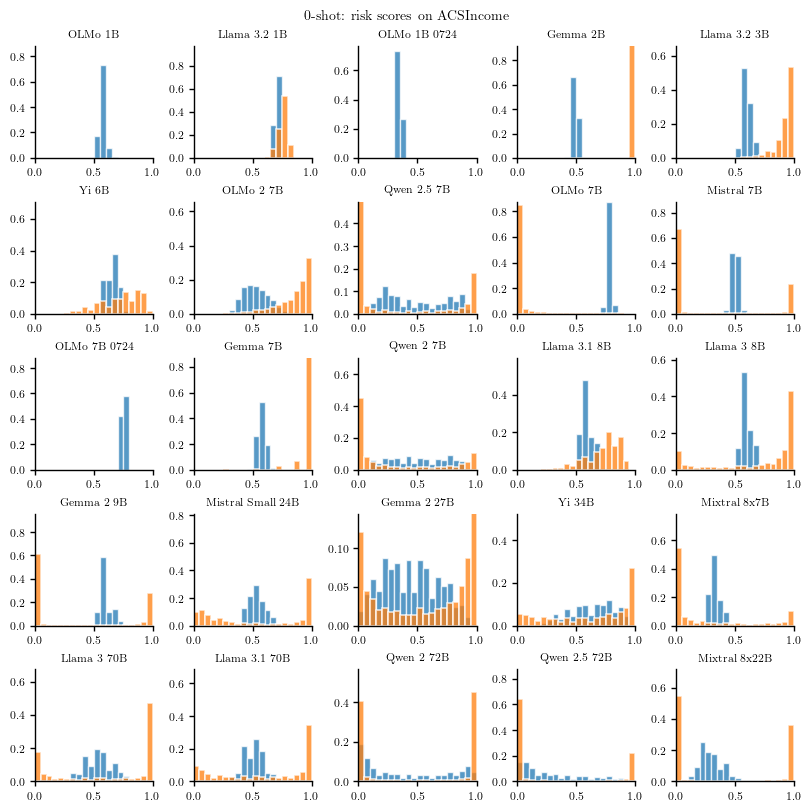

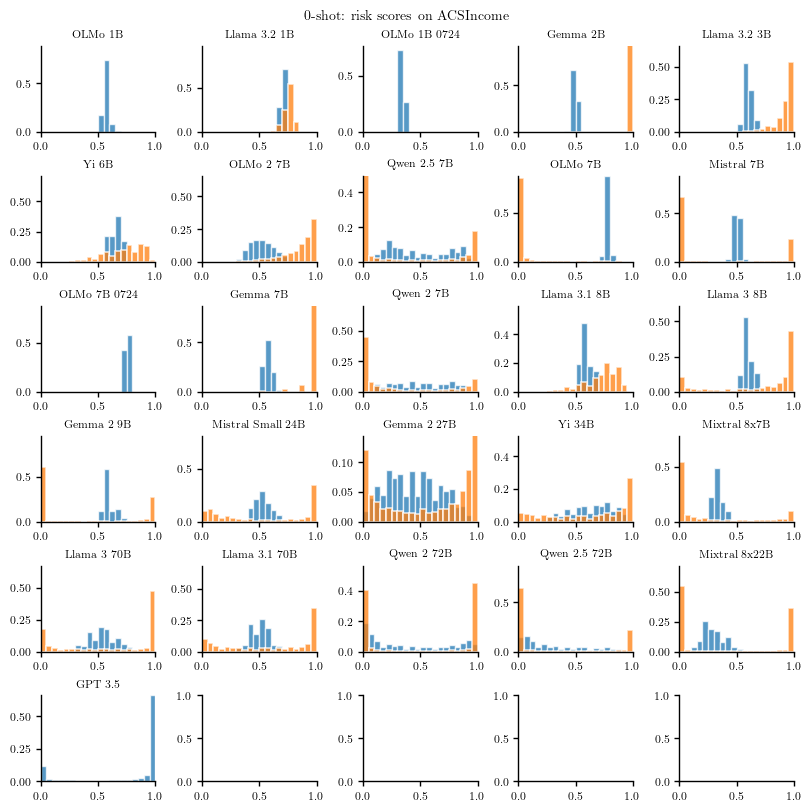

ACSEmployment


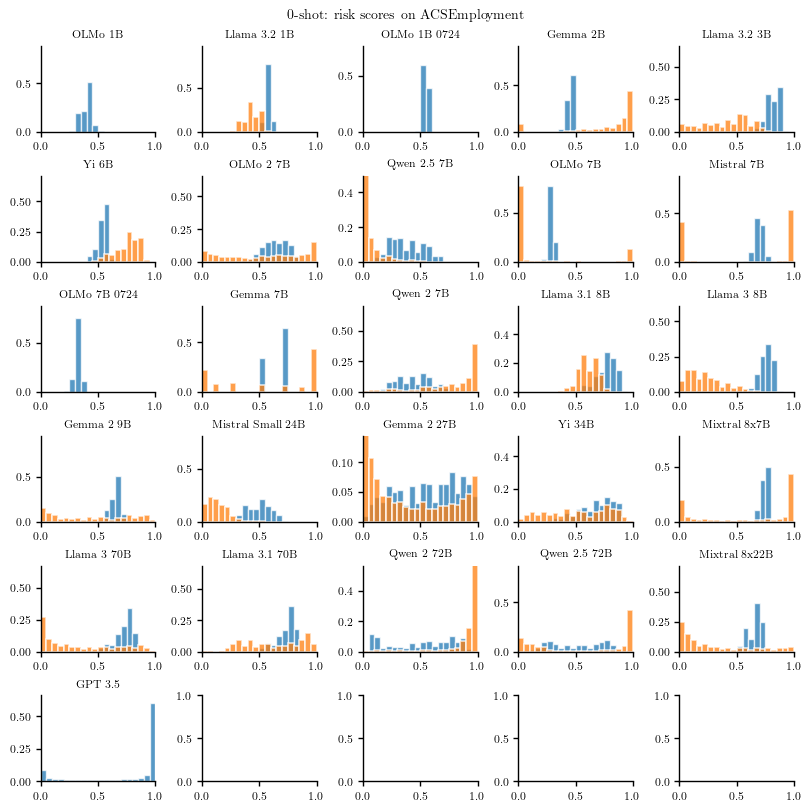

ACSMobility


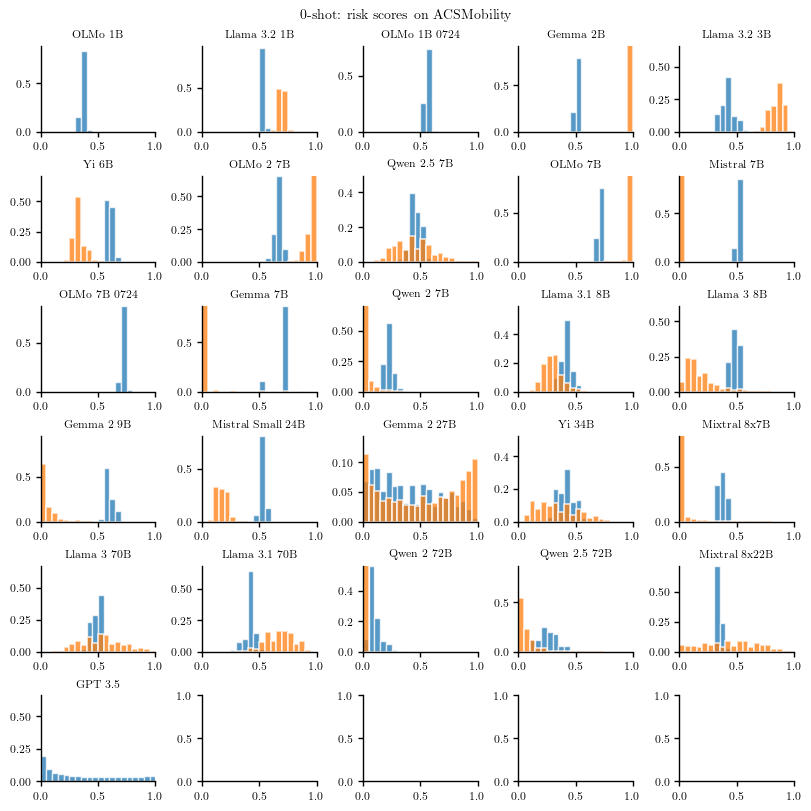

ACSTravelTime


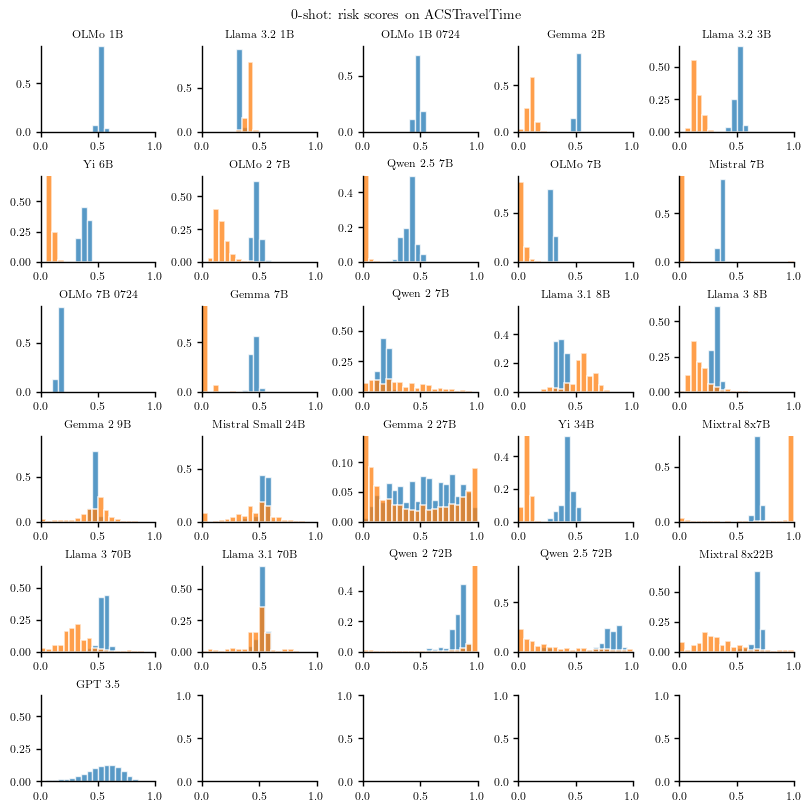

ACSPublicCoverage


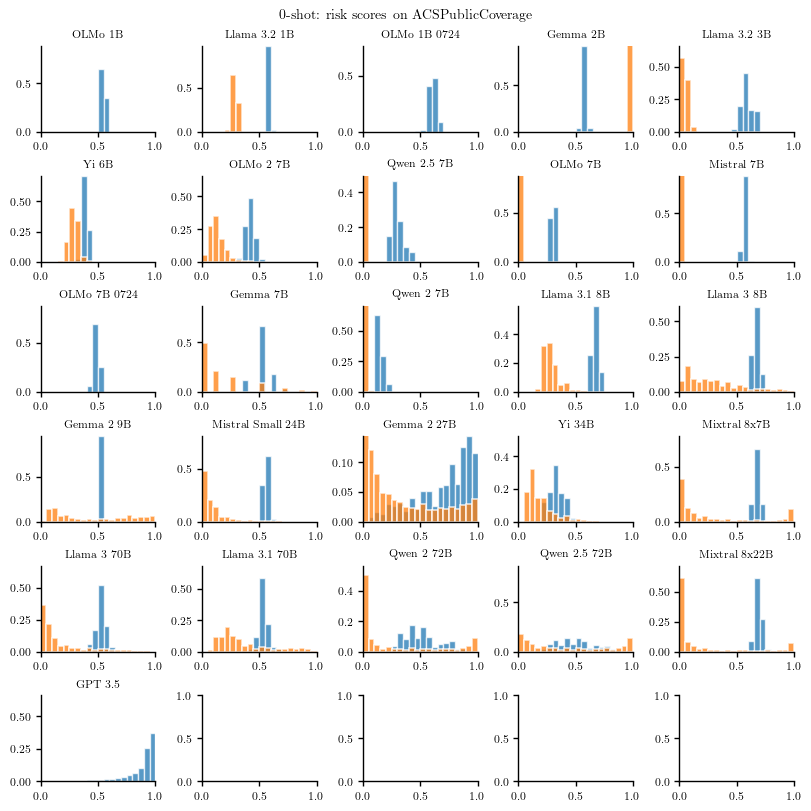

BRFSS_Diabetes


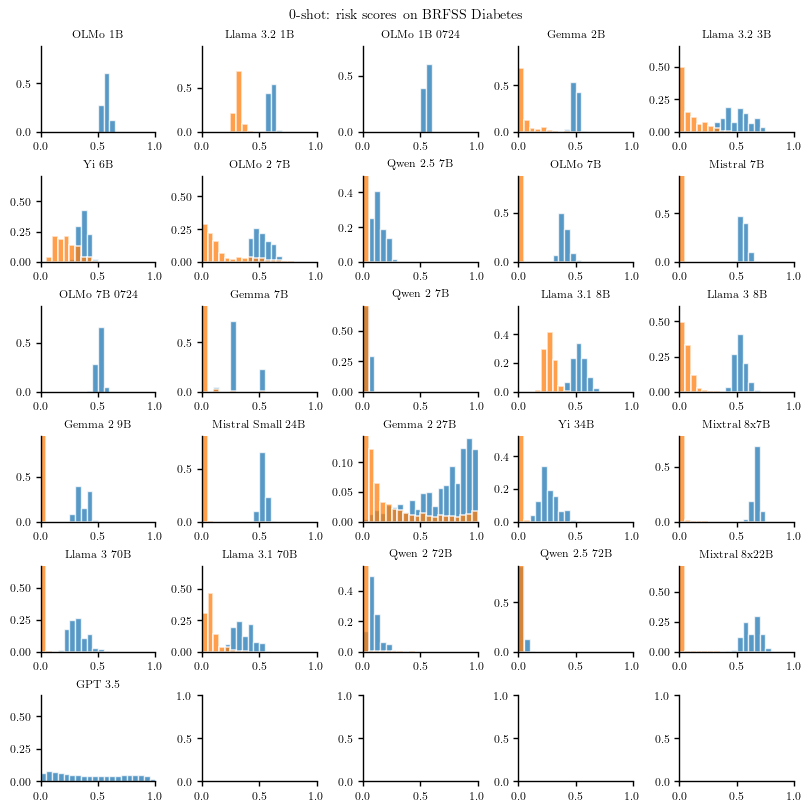

BRFSS_Blood_Pressure


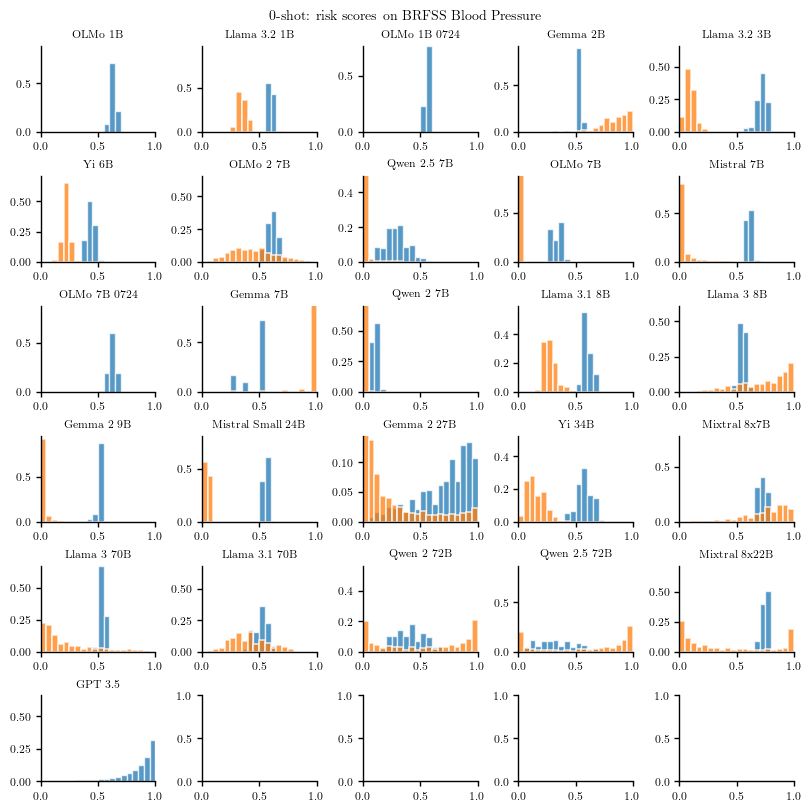

In [ ]:
base_models = sorted(
    [model for model in models_common if not is_instruction_tuned(model)],
    key=get_size,
)
it_models = sorted(
    [model for model in models_common if is_instruction_tuned(model)],
    key=get_size,
)
len(base_models), len(it_models)

# to ensure axis are the same across plots, get max y value per model
ymax = {}
for model in base_models:
    ymax[model] = 0
    for task in TASKS:
        N = risk_scores[task].shape[0]
        task_max = max(
            np.histogram(
                risk_scores[task][model],
                weights=np.zeros((N,)) + 1.0 / N,
                bins=np.arange(0, 1.01, 0.05),
            )[0]
        )
        if task_max > ymax[model]:
            ymax[model] = task_max


for task in TASKS:
    print(task)
    N = risk_scores[task].shape[0]
    num_row, num_col = 6, 5
    fig, axs = plt.subplots(num_row, num_col, figsize=(8, 8), constrained_layout=True)
    fig.suptitle(f"{num_shots}-shot: risk scores on {task.replace('_', ' ')}")
    for i, model in enumerate(base_models):

        coresponding_it_model = [
            itm
            for itm in it_models
            if prettify_model_name(key_to_model(itm)).startswith(
                prettify_model_name(key_to_model(model))
            )
        ]
        # print(model, coresponding_it_model)

        axs[i // num_col, i % num_col].set_xlim(0.0, 1.0)
        axs[i // num_col, i % num_col].set_title(
            prettify_model_name(key_to_model(model))
        )
        ys, xs, _ = axs[i // num_col, i % num_col].hist(
            risk_scores[task][model],
            weights=np.zeros((N,)) + 1.0 / N,
            alpha=0.75,
            label="base",
            bins=np.arange(0, 1.01, 0.05),
            edgecolor="w",
            linewidth=1,
        )
        axs[i // num_col, i % num_col].set_ylim(0.0, ymax[model])
        if len(coresponding_it_model) == 1:
            axs[i // num_col, i % num_col].hist(
                risk_scores[task][coresponding_it_model[0]],
                weights=np.zeros((N,)) + 1.0 / N,
                alpha=0.75,
                label="it",
                bins=np.arange(0, 1.01, 0.05),
                edgecolor="w",
                linewidth=1.2,
            )
    axs[-1, -1].legend()

    file_name = "".join(
        [
            f"risk-scores-{num_shots}-shot",
            f"-{task}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.show()